## **1. Import Library**

In [1]:
# Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

## **2. Memuat Dataset**

In [2]:
# Load dataset
url = "https://drive.google.com/uc?id=1D0Zb-4LztkoTAEePhXUazXIdctoHfFmR"
df = pd.read_csv(url)

df.head()

,Date,title,category,account,amount,currency,type,transfer-amount,transfer-currency,to-account,receive-amount,receive-currency,description,due-date,id
0,2024-08-11 13:56:59.652,Karthik,Bills & Fees,Savings Bank,45.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74e78631-db14-4495-bfb9-85546b0bd2fe
1,2024-08-10 16:09:55.986,Juice,Food & Drinks,Cash,40.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65e12e62-9f63-4c6c-b452-6c7b42fbfb7f
2,2024-08-09 10:25:21.618,Tire,Transport,Cash,10.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9ecd93bd-a835-4263-86e2-99fea475fa37
3,2024-08-07 03:57:24.944,Baba,Bills & Fees,Savings Bank,200.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00d39b2c-e722-485a-85ca-28f6506dc674
4,2024-08-04 13:09:08.452,Reward,Bills & Fees,Salary Bank,4.00,INR,INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861d205-3245-4926-ad69-4491b0bff547


In [3]:
# Informasi Dataset
print("Informasi Dataset : ")
df.info()

df.describe()

Informasi Dataset : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1155 non-null   object 
 1   title              1131 non-null   object 
 2   category           994 non-null    object 
 3   account            1155 non-null   object 
 4   amount             1155 non-null   object 
 5   currency           1155 non-null   object 
 6   type               1155 non-null   object 
 7   transfer-amount    44 non-null     object 
 8   transfer-currency  44 non-null     object 
 9   to-account         44 non-null     object 
 10  receive-amount     44 non-null     object 
 11  receive-currency   44 non-null     object 
 12  description        1 non-null      float64
 13  due-date           0 non-null      float64
 14  id                 1155 non-null   object 
dtypes: float64(2), object(13)
memory usage: 135.5+ KB


,description,due-date
count,1.000000e+00,0.0
mean,8.500264e+09,NaN
std,NaN,NaN
min,8.500264e+09,NaN
25%,8.500264e+09,NaN
50%,8.500264e+09,NaN
75%,8.500264e+09,NaN
max,8.500264e+09,NaN


## **3. Preprocessing Data**

In [4]:
# Hapus data kurang berguna
drop_cols = [
    'id', 'title', 'currency',
    'transfer-amount', 'transfer-currency',
    'to-account', 'receive-amount', 'receive-currency',
    'description', 'due-date'
]
df = df.drop(columns=drop_cols)

df.head()


,Date,category,account,amount,type
0,2024-08-11 13:56:59.652,Bills & Fees,Savings Bank,45.00,EXPENSE
1,2024-08-10 16:09:55.986,Food & Drinks,Cash,40.00,EXPENSE
2,2024-08-09 10:25:21.618,Transport,Cash,10.00,EXPENSE
3,2024-08-07 03:57:24.944,Bills & Fees,Savings Bank,200.00,EXPENSE
4,2024-08-04 13:09:08.452,Bills & Fees,Salary Bank,4.00,INCOME


In [5]:
# Konversi amount ke numeric
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

In [6]:
# Missing Value
print("Missing Value : ")
df.isnull().sum()

Missing Value : 


,0
Date,0
category,161
account,0
amount,63
type,0


In [7]:
# Penanganan Missing Value
df['category'] = df['category'].fillna(df['category'].mode()[0])
df['amount'] = df['amount'].fillna(df['amount'].median())

df.isnull().sum()

,0
Date,0
category,0
account,0
amount,0
type,0


In [8]:
# Data Duplikat
print("Data Duplikat : ")
df.duplicated().sum()

Data Duplikat : 


np.int64(3)

In [9]:
# Modifikasi amount
df['amount'] = df['amount'] * 1000
df.head()

,Date,category,account,amount,type
0,2024-08-11 13:56:59.652,Bills & Fees,Savings Bank,45000.0,EXPENSE
1,2024-08-10 16:09:55.986,Food & Drinks,Cash,40000.0,EXPENSE
2,2024-08-09 10:25:21.618,Transport,Cash,10000.0,EXPENSE
3,2024-08-07 03:57:24.944,Bills & Fees,Savings Bank,200000.0,EXPENSE
4,2024-08-04 13:09:08.452,Bills & Fees,Salary Bank,4000.0,INCOME


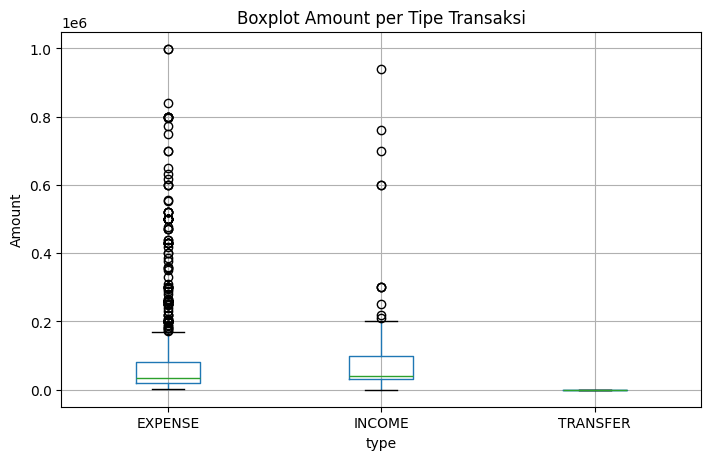

In [10]:
#Outlier
df.boxplot(column='amount', by='type', figsize=(8, 5))
plt.title('Boxplot Amount per Tipe Transaksi')
plt.suptitle('')
plt.ylabel('Amount')
plt.show()

In [11]:
# Pecah Kolom Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['year_month'] = df['Date'].dt.to_period('M').astype(str)
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df=df.drop(columns='Date')

df.head()

,category,account,amount,type,year_month,year,month,day
0,Bills & Fees,Savings Bank,45000.0,EXPENSE,2024-08,2024,8,11
1,Food & Drinks,Cash,40000.0,EXPENSE,2024-08,2024,8,10
2,Transport,Cash,10000.0,EXPENSE,2024-08,2024,8,9
3,Bills & Fees,Savings Bank,200000.0,EXPENSE,2024-08,2024,8,7
4,Bills & Fees,Salary Bank,4000.0,INCOME,2024-08,2024,8,4


In [12]:
# Validasi Informasi Dataset
print("Informasi Dataset : ")
df.info()

df.describe()

Informasi Dataset : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   category    1155 non-null   object 
 1   account     1155 non-null   object 
 2   amount      1155 non-null   float64
 3   type        1155 non-null   object 
 4   year_month  1155 non-null   object 
 5   year        1155 non-null   int32  
 6   month       1155 non-null   int32  
 7   day         1155 non-null   int32  
dtypes: float64(1), int32(3), object(4)
memory usage: 58.8+ KB


,amount,year,month,day
count,1155.000000,1155.000000,1155.000000,1155.000000
mean,84347.826840,2023.541991,6.019913,16.279654
std,140093.997334,0.498449,3.371116,9.083699
min,0.000000,2023.000000,1.000000,1.000000
25%,20000.000000,2023.000000,4.000000,8.000000
50%,35000.000000,2024.000000,5.000000,17.000000
75%,80000.000000,2024.000000,9.000000,24.000000
max,999000.000000,2024.000000,12.000000,31.000000


In [13]:
df.to_csv('Financial_Transactions.csv', index=False)

## **4. Exploratory Data Analysis (EDA)**

Pertanyaan Bisnis
1. Bagaimana tren pengeluaran per bulan?
2. Apa kategori pengeluaran tertinggi dan terendah di setiap bulan?
3. Apakah ada kategori pengeluaran yang tergolong melampaui batas normal di tiap bulannya?
4. Apa kategori pengeluaran yang sering dilakukan tiap bulannya?

note: mencari karakteristik data >> eda
eda untuk mempelajari hubungan feature satu dengan feature lainnya.


In [14]:
# mencari tahu jumlah baris dan kolom
df.shape

(1155, 8)

In [15]:
# Statistik deskriptif
df.describe()

,amount,year,month,day
count,1155.000000,1155.000000,1155.000000,1155.000000
mean,84347.826840,2023.541991,6.019913,16.279654
std,140093.997334,0.498449,3.371116,9.083699
min,0.000000,2023.000000,1.000000,1.000000
25%,20000.000000,2023.000000,4.000000,8.000000
50%,35000.000000,2024.000000,5.000000,17.000000
75%,80000.000000,2024.000000,9.000000,24.000000
max,999000.000000,2024.000000,12.000000,31.000000


<Axes: xlabel='amount', ylabel='Count'>

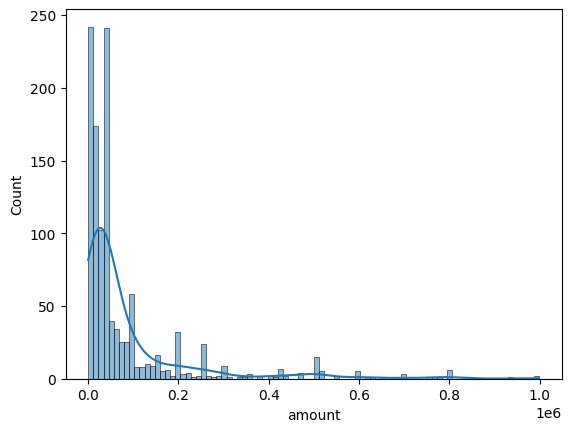

In [16]:
# menampilkan histogram untuk kolom numerik amount dan melihat distribusi data amount
sns.histplot(df['amount'], kde=True)

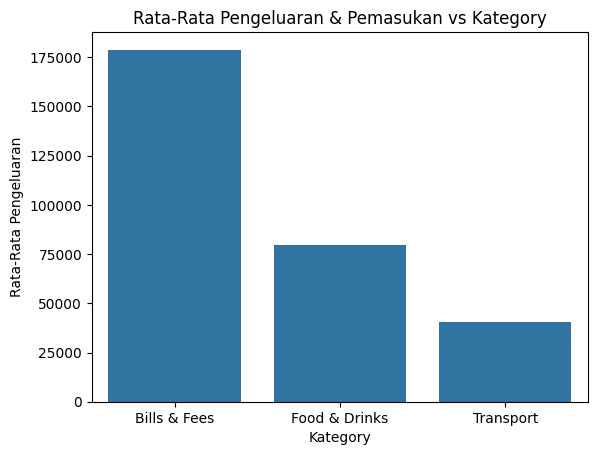

In [17]:
# Amount vs category
sns.barplot(x='category', y='amount', data=df, errorbar=None)
plt.title('Rata-Rata Pengeluaran & Pemasukan vs Kategory')
plt.xlabel('Kategory')
plt.ylabel('Rata-Rata Pengeluaran')
plt.show()

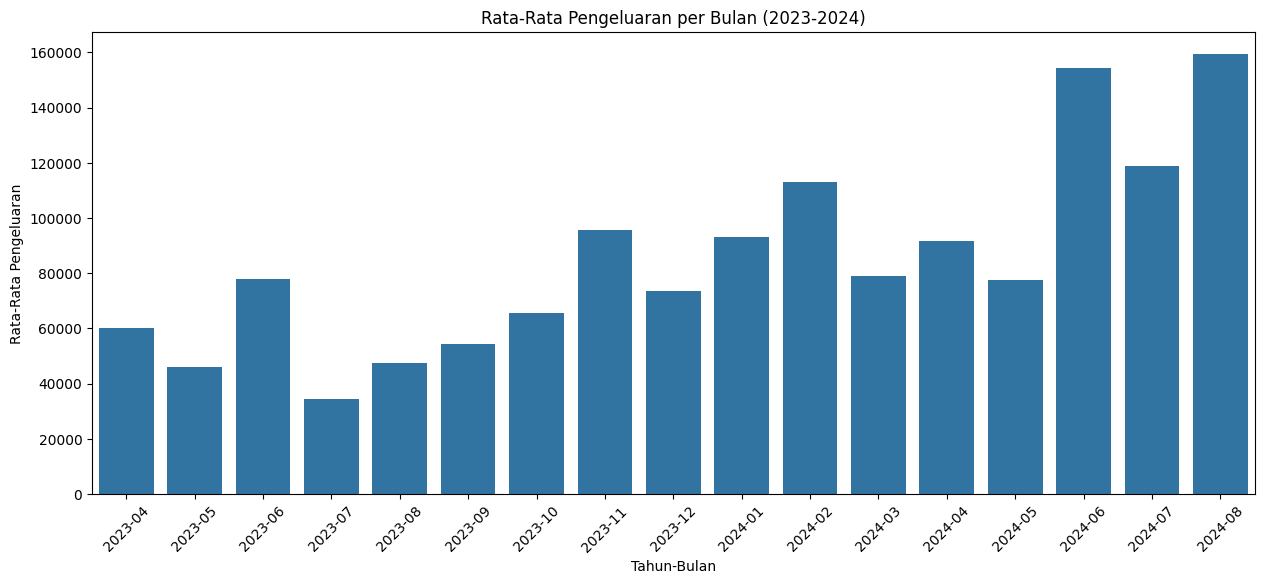

In [18]:
# Fluktuasi pengeluaran tiap bulannya
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

df_plot = df[
    (df['year'] >= 2023) &
    (df['year'] <= 2024) &
    (df['type'] == 'EXPENSE')
].copy()

df_plot = df_plot.sort_values(by='year_month')

order_year_month = df_plot['year_month'].unique()

plt.figure(figsize=(15, 6))
sns.barplot(
    x='year_month',
    y='amount',
    data=df_plot,
    estimator='mean',
    errorbar=None,
    order=order_year_month
)

plt.title('Rata-Rata Pengeluaran per Bulan (2023-2024)')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Rata-Rata Pengeluaran')
plt.xticks(rotation=45)
plt.show()

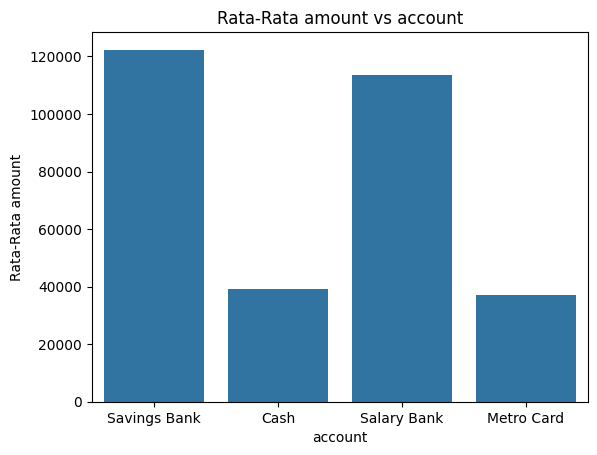

In [19]:
# Amount vs account
sns.barplot(x='account', y='amount', data=df, errorbar=None)
plt.title('Rata-Rata amount vs account')
plt.xlabel('account')
plt.ylabel('Rata-Rata amount')
plt.show()

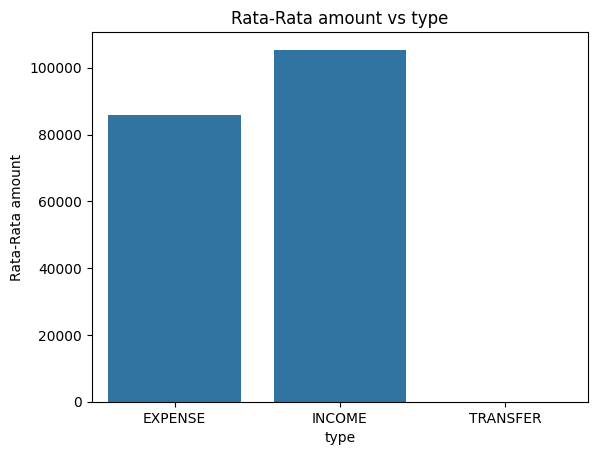

In [20]:
# Amount vs Type
sns.barplot(x='type', y='amount', data=df, errorbar=None)
plt.title('Rata-Rata amount vs type')
plt.xlabel('type')
plt.ylabel('Rata-Rata amount')
plt.show()

MENJAWAB PERTANYAAN BISNIS

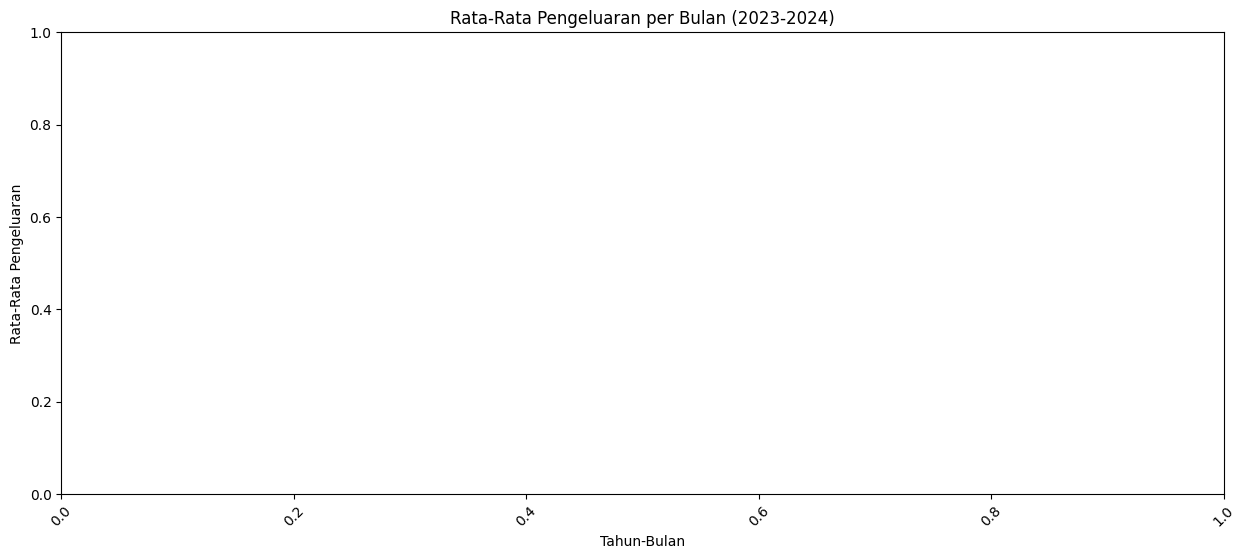

In [21]:
# Bagaimana tren pengeluaran per bulan pada tahun 2023 dan 2024?
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

df_plot = df[(df['year'] >= 2023) & (df['year'] <= 2024) & (df['type'] == 0)].copy()
df_plot = df_plot.sort_values(by='year_month')

order_year_month = df_plot['year_month'].unique()

plt.figure(figsize=(15, 6))
sns.barplot(
    x='year_month',
    y='amount',
    data=df_plot,
    estimator='mean',
    errorbar=None,
    order=order_year_month
)

plt.title('Rata-Rata Pengeluaran per Bulan (2023-2024)')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Rata-Rata Pengeluaran')
plt.xticks(rotation=45)
plt.show()

Pengeluaran tiap bulan memiliki tren naik dan tiap bulan cenderung berfluktuatif. pengeluaran terbesar terlihat pada bulan juni dan agustus tahun 2024

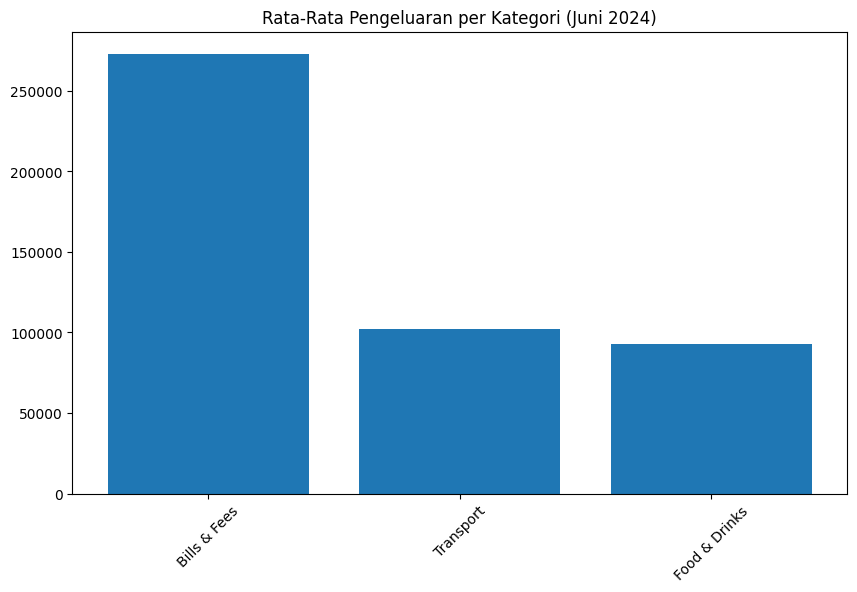

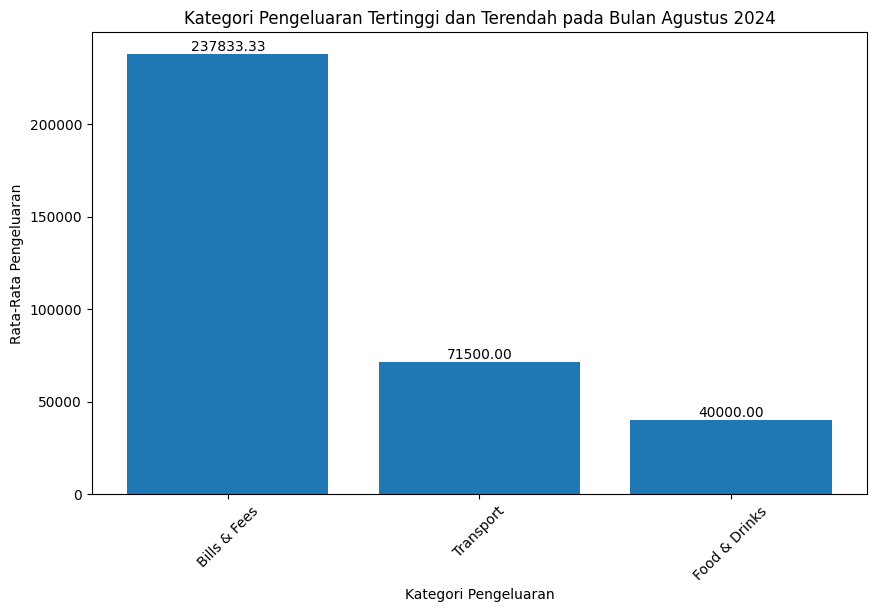

Tertinggi Agustus: Kategori Bills & Fees
Terendah Agustus: Kategori Food & Drinks


In [22]:
# Juni
kategori_pengeluaran_juni = df[
    (df['year_month'] == '2024-06') &
    (df['type'] == 'EXPENSE')
]

kategori_pengeluaran_juni = kategori_pengeluaran_juni.groupby('category')['amount'].mean().reset_index()
kategori_pengeluaran_juni = kategori_pengeluaran_juni.sort_values(by='amount', ascending=False)

tertinggi_juni = kategori_pengeluaran_juni.iloc[0]['category']
terendah_juni = kategori_pengeluaran_juni.iloc[-1]['category']

plt.figure(figsize=(10, 6))
plt.bar(kategori_pengeluaran_juni['category'], kategori_pengeluaran_juni['amount'])

plt.title('Rata-Rata Pengeluaran per Kategori (Juni 2024)')
plt.xticks(rotation=45)
plt.show()

#Agustus
kategori_pengeluaran_agustus = df[(df['year_month'] == '2024-08') & (df['type'] == 'EXPENSE')]
kategori_pengeluaran_agustus = kategori_pengeluaran_agustus.groupby('category')['amount'].mean().reset_index()
kategori_pengeluaran_agustus = kategori_pengeluaran_agustus.sort_values(by='amount', ascending=False)
tertinggi_agustus = kategori_pengeluaran_agustus.iloc[0]['category']
terendah_agustus = kategori_pengeluaran_agustus.iloc[-1]['category']

plt.figure(figsize=(10, 6))
plt.bar(kategori_pengeluaran_agustus['category'], kategori_pengeluaran_agustus['amount'])
plt.xticks(
    ticks=range(len(kategori_pengeluaran_agustus['category'])),
    labels=kategori_pengeluaran_agustus['category'],
    rotation=45
)
plt.title('Kategori Pengeluaran Tertinggi dan Terendah pada Bulan Agustus 2024')
plt.xlabel('Kategori Pengeluaran')
plt.ylabel('Rata-Rata Pengeluaran')
for index, row in kategori_pengeluaran_agustus.iterrows():
    plt.text(row['category'], row['amount'], f'{row["amount"]:.2f}', ha='center', va='bottom')
plt.show()

print(f"Tertinggi Agustus: Kategori {tertinggi_agustus}")
print(f"Terendah Agustus: Kategori {terendah_agustus}")

Kategori pengeluaran tertinggi di bulan Juni dan Agustus 2024 adalah kategori 0.

In [23]:
from pandas._libs.tslibs.offsets import MonthBegin

# Apakah ada kategori pengeluaran yang tergolong melampaui batas normal di tiap bulannya?
df_expense = df[df['type'] == 'EXPENSE']

monthly_avg = df_expense.groupby(['year_month', 'category'])['amount'].mean().reset_index()
normal_avg = df_expense.groupby('category')['amount'].mean().reset_index().rename(columns={'amount': 'normal_avg_amount'})

compare_df = pd.merge(monthly_avg, normal_avg, on='category')

compare_df['Melampaui_Normal'] = compare_df['amount'] > compare_df['normal_avg_amount']

over_limit = compare_df[compare_df['Melampaui_Normal'] == True]
print(over_limit[['year_month', 'category', 'amount', 'normal_avg_amount']])

frekuensi = (
    compare_df[compare_df['Melampaui_Normal'] == True]
    .groupby('category')
    .size()
    .reset_index(name='Jumlah_Bulan_Di_Atas_Rata2')
)

print()
print("Frekuensi Kategori Melampaui Batas Normal:")
print(frekuensi)


   year_month       category         amount  normal_avg_amount
0     2023-04   Bills & Fees  219000.000000      192972.597403
5     2023-05      Transport   45157.894737       39734.186508
6     2023-06   Bills & Fees  285654.000000      192972.597403
19    2023-10  Food & Drinks  110857.142857       80452.710623
22    2023-11  Food & Drinks  211571.428571       80452.710623
24    2023-12   Bills & Fees  223487.500000      192972.597403
28    2024-01  Food & Drinks   93823.529412       80452.710623
30    2024-02   Bills & Fees  271846.153846      192972.597403
31    2024-02  Food & Drinks   82100.000000       80452.710623
32    2024-02      Transport   41184.081633       39734.186508
35    2024-03      Transport   44515.151515       39734.186508
36    2024-04   Bills & Fees  310868.571429      192972.597403
37    2024-04  Food & Drinks   82811.081081       80452.710623
38    2024-04      Transport   42517.678571       39734.186508
41    2024-05      Transport   40000.000000       39734

Kategori yang paling sering berada di atas rata-rata pengeluaran adalah kategori 2

In [24]:
# Apa kategori pengeluaran yang sering dilakukan tiap bulannya?
frekuensi_bulanan = df.groupby('year_month')['category'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'No Category').reset_index()
print("Kategori Pengeluaran Paling Sering Dilakukan Tiap Bulannya:")
print(frekuensi_bulanan)

Kategori Pengeluaran Paling Sering Dilakukan Tiap Bulannya:
   year_month      category
0     2023-04     Transport
1     2023-05     Transport
2     2023-06     Transport
3     2023-07     Transport
4     2023-08     Transport
5     2023-09     Transport
6     2023-10     Transport
7     2023-11     Transport
8     2023-12     Transport
9     2024-01  Bills & Fees
10    2024-02     Transport
11    2024-03     Transport
12    2024-04     Transport
13    2024-05     Transport
14    2024-06  Bills & Fees
15    2024-07  Bills & Fees
16    2024-08  Bills & Fees


Kategori yang paling sering dikeluarkan untuk tiap bulannya adalah Transport

## **5. Feature Engenering**

In [25]:
# one Hot Encoding
df_encoded = pd.get_dummies(df, columns=['category', 'account', 'type'])
df_encoded

,amount,year_month,year,month,day,category_Bills & Fees,category_Food & Drinks,category_Transport,account_Cash,account_Metro Card,account_Salary Bank,account_Savings Bank,type_EXPENSE,type_INCOME,type_TRANSFER
0,45000.0,2024-08,2024,8,11,True,False,False,False,False,False,True,True,False,False
1,40000.0,2024-08,2024,8,10,False,True,False,True,False,False,False,True,False,False
2,10000.0,2024-08,2024,8,9,False,False,True,True,False,False,False,True,False,False
3,200000.0,2024-08,2024,8,7,True,False,False,False,False,False,True,True,False,False
4,4000.0,2024-08,2024,8,4,True,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,7000.0,2023-04,2023,4,22,False,False,True,True,False,False,False,False,True,False
1151,300000.0,2023-04,2023,4,22,False,False,True,False,False,False,True,False,True,False
1152,139000.0,2023-04,2023,4,22,False,False,True,False,True,False,False,False,True,False
1153,35000.0,2023-04,2023,4,22,False,False,True,False,False,False,True,False,True,False


In [26]:
# save data hasil encoded
df_encoded.to_csv('Financial_Transactions_encoded.csv', index=False)